In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score

In [5]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
print(df.shape)
print(df.columns)

df.info() # datatypes + null
df.describe() # statistics

(545, 13)
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
print(df.isnull().sum())

for col in df.select_dtypes(include=np.number).columns :
  df[col].fillna(df[col].mean() , inplace = True)

for col in df.select_dtypes(include='object').columns:
  df[col].fillna(df[col].mode()[0] , inplace = True)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


/tmp/ipykernel_10273/3666248997.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean() , inplace = True)
/tmp/ipykernel_10273/3666248997.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

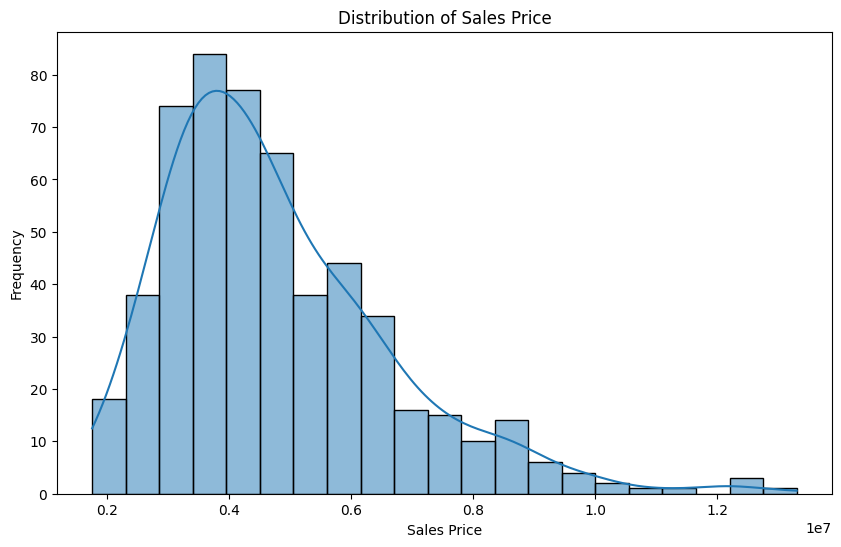

In [9]:
# EDA

plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Sales Price')
plt.xlabel('Sales Price')
plt.ylabel('Frequency')
plt.show()

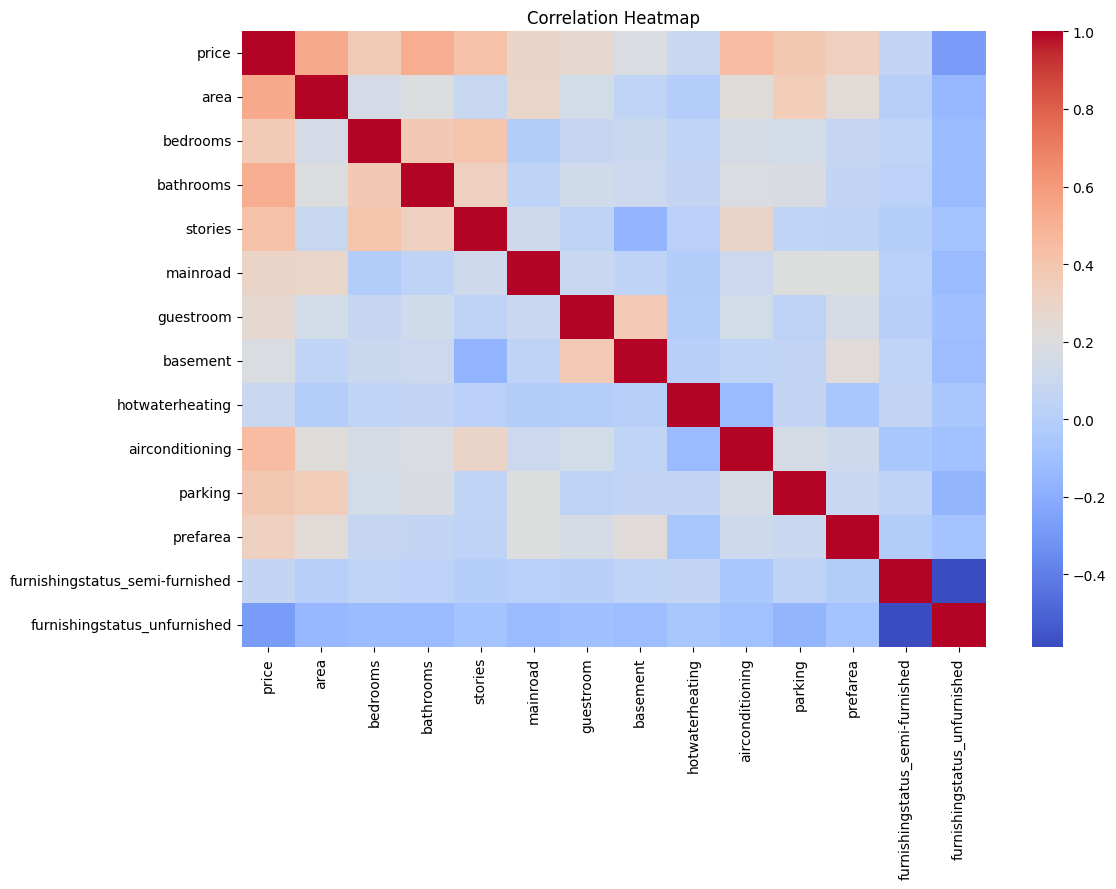

In [11]:
# Fix for the error: Convert categorical columns to numerical before calculating correlation
df_temp_corr = df.copy()

# Map binary 'yes'/'no' columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df_temp_corr[col] = df_temp_corr[col].map({'yes': 1, 'no': 0})

# One-hot encode the 'furnishingstatus' column
df_temp_corr = pd.get_dummies(df_temp_corr, columns=['furnishingstatus'], drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(df_temp_corr.corr(), cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [12]:
df = pd.get_dummies(df,drop_first=True)

In [13]:
X = df.drop('price',axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
model = LinearRegression()
model.fit(X_train , y_train)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test , y_pred)

print("Mean Absolute Error", mae)
print("Mean Squared Error", mse)
print("Root Mean Squared Error", rmse)
print("R-squared", r2)

Mean Absolute Error 970043.4039201636
Mean Squared Error 1754318687330.6638
Root Mean Squared Error 1324506.9600914386
R-squared 0.6529242642153184


In [18]:
import pickle
pickle.dump(model , open('house_price_model.pkl' , 'wb'))

In [19]:
loaded_model = pickle.load(open("house_price_model.pkl" , "rb"))
sample = X_test.iloc[0:1]
prediction = loaded_model.predict(sample)
print(prediction)

[5164653.90033967]


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.svm import SVR

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Machine': SVR()
}

In [24]:
results = []

for name, model_instance in models.items():
  model_instance.fit(X_train , y_train)
  preds = model_instance.predict(X_test)

  mae = mean_absolute_error(y_test , preds)
  mse = mean_squared_error(y_test , preds)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test , preds)

  results.append ({
      "Model": name,
      "MAE": mae,
      "MSE": mse,
      "RMSE": rmse,
      "R2": r2
  })

In [28]:
results_df = pd.DataFrame(results)
results_df.sort_values(by = "R2", ascending = False)

,Model,MAE,MSE,RMSE,R2
3,Gradient Boosting,9.597490e+05,1.688404e+12,1.299386e+06,0.665965
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
2,Random Forest,1.021546e+06,1.961585e+12,1.400566e+06,0.611919
1,Decision Tree,1.195266e+06,2.642803e+12,1.625670e+06,0.477146
4,Support Vector Machine,1.763890e+06,5.567932e+12,2.359647e+06,-0.101564
